# Lab 1
## Dynamic model of a multi-link manipulator

First laboratory work for the course Robot Motion Planning and Control.

Selected robot: **Stanford manipulator**  

## Steps

### 0. Import the necessary libraries

In [1]:
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

### 1. Import robot model (Stanford)

In [2]:
robot = rtb.models.DH.Stanford()
print(robot)
print("Number of joints =", robot.n)
print("Joint types =", ["Revolute" if link.sigma == 0 else "Prismatic" for link in robot.links])

DHRobot: Stanford arm (by Victor Scheinman), 6 joints (RRPRRR), dynamics, standard DH parameters
┌────────┬───────┬────────┬────────┬─────────────────────┬────────┐
│   θⱼ   │  dⱼ   │   aⱼ   │   ⍺ⱼ   │         q⁻          │   q⁺   │
├────────┼───────┼────────┼────────┼─────────────────────┼────────┤
│  q1    │ 0.412 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q2    │ 0.154 │      0 │  90.0° │             -170.0° │ 170.0° │
│ -90.0° │    q3 │ 0.0203 │   0.0° │ 0.30479999999999996 │   1.27 │
│  q4    │     0 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q5    │     0 │      0 │  90.0° │              -90.0° │  90.0° │
│  q6    │     0 │      0 │   0.0° │             -170.0° │ 170.0° │
└────────┴───────┴────────┴────────┴─────────────────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬─────┬────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2 │ q3  │ q4  │ q5  │
├──────┼─────┼─────┼────┼─────┼─────┼─────┤
│   qr │  0° │  0° │  0 │  0° │  0° │  0° │
│   qz │  0° │  0° │  0 │  0°

## Denavit-Hartenberg parameters

In [3]:
dh_table = []

for i, link in enumerate(robot.links):
    dh_table.append([
        i+1,
        link.a,
        link.alpha,
        link.d,
        link.theta,
        link.offset,
        link.sigma
    ])

df_dh = pd.DataFrame(
    dh_table,
    columns=["Link", "a", "alpha", "d", "theta", "offset", "sigma"]
)

print(df_dh)

   Link       a     alpha      d     theta  offset  sigma
0     1  0.0000 -1.570796  0.412  0.000000     0.0      0
1     2  0.0000  1.570796  0.154  0.000000     0.0      0
2     3  0.0203  0.000000  0.000 -1.570796     0.0      1
3     4  0.0000 -1.570796  0.000  0.000000     0.0      0
4     5  0.0000  1.570796  0.000  0.000000     0.0      0
5     6  0.0000  0.000000  0.000  0.000000     0.0      0


### 2. Fill in the parameters of the robot model (in the example, filled in for the Puma560 robot)

0. Using dyn() you can view the dynamic parameters of each link

In [4]:
print(robot.links[0].dyn()) # initial dynamic parameters of the first link

m     =       9.3 
r     =         0    0.018    -0.11 
        |     0.28        0        0 | 
I     = |        0     0.26        0 | 
        |        0        0    0.071 | 
Jm    =      0.95 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =        -3 to        3


1. Let's define the mass of the links

In [5]:
robot.links[0].m = 9.29
robot.links[1].m = 5.01
robot.links[2].m = 4.25
robot.links[3].m = 1.08
robot.links[4].m = 0.63
robot.links[5].m = 0.51

2. Let's define the center of mass of each link

In [6]:
robot.links[0].r = [0, 0.0175, -0.1105]
robot.links[1].r = [0, -1.054, 0]
robot.links[2].r = [0, 0, -6.447]
robot.links[3].r = [0, 0.092, -0.054]
robot.links[4].r = [0, 0.566, 0.003]
robot.links[5].r = [0, 0, 1.554]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [7]:
robot.links[0].I = [0.276, 0.255, 0.071, 0, 0, 0]
robot.links[1].I = [0.108, 0.018, 0.100, 0, 0, 0]
robot.links[2].I = [2.51, 2.51, 0.006, 0, 0, 0]
robot.links[3].I = [0.002, 0.001, 0.001, 0, 0, 0]
robot.links[4].I = [0.003, 0.0004, 0, 0, 0, 0]
robot.links[5].I = [0.013, 0.013, 0.0003, 0, 0, 0]

4. Let's set the moment of inertia of the drive

In [8]:
robot.links[0].Jm = 0.953
robot.links[1].Jm = 2.193
robot.links[2].Jm = 0.782
robot.links[3].Jm = 0.106
robot.links[4].Jm = 0.097
robot.links[5].Jm = 0.020

5. Let's define the coefficient of viscous friction of the drive

In [9]:
robot.links[0].B = 0
robot.links[1].B = 0
robot.links[2].B = 0
robot.links[3].B = 0
robot.links[4].B = 0
robot.links[5].B = 0

6. Let's define the coefficient of Coulomb friction of the drive

In [10]:
robot.links[0].Tc = [0, 0]
robot.links[1].Tc = [0, 0]
robot.links[2].Tc = [0, 0]
robot.links[3].Tc = [0, 0]
robot.links[4].Tc = [0, 0]
robot.links[5].Tc = [0, 0]

7. Let's set the gear ratio for each link

In [11]:

robot.links[0].G = 1
robot.links[1].G = 1
robot.links[2].G = 1
robot.links[3].G = 1
robot.links[4].G = 1
robot.links[5].G = 1

8. Let's set restrictions on the generalized coordinates for each link

In [12]:
robot.links[0].qlim = [-2.9671, 2.9671]
robot.links[1].qlim = [-2.9671, 2.9671]
robot.links[2].qlim = [0.3048, 1.27]
robot.links[3].qlim = [-2.9671, 2.9671]
robot.links[4].qlim = [-1.5708, 1.5708]
robot.links[5].qlim = [-2.9671, 2.9671]

In [13]:
for i in range(robot.n):
    print(f"\nLink {i+1}")
    print(robot.links[i].dyn())


Link 1
m     =       9.3 
r     =         0    0.018    -0.11 
        |     0.28        0        0 | 
I     = |        0     0.26        0 | 
        |        0        0    0.071 | 
Jm    =      0.95 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =        -3 to        3

Link 2
m     =         5 
r     =         0     -1.1        0 
        |     0.11        0        0 | 
I     = |        0    0.018        0 | 
        |        0        0      0.1 | 
Jm    =       2.2 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =        -3 to        3

Link 3
m     =       4.2 
r     =         0        0     -6.4 
        |      2.5        0        0 | 
I     = |        0      2.5        0 | 
        |        0        0    0.006 | 
Jm    =      0.78 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =       0.3 to      1.3

Link 4
m     =       1.1 
r     =         0    0.092   -0.054 
        |    0.002   

## 3. Set the initial and final positions of the robot and plot them

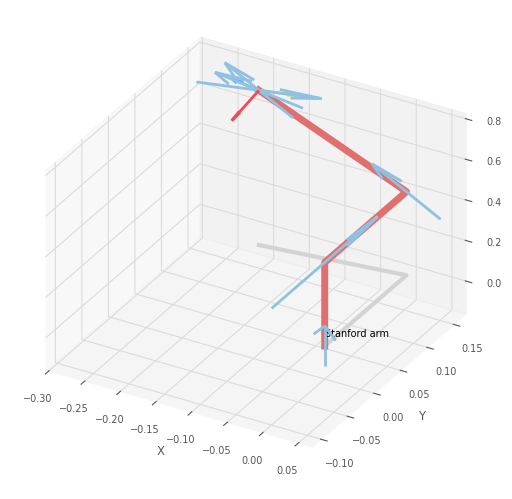

<Figure size 640x480 with 0 Axes>

In [14]:
q_start = np.array([0, -0.5, 0.40, 0, 0.2, 0])
robot.plot(q_start)
plt.show()

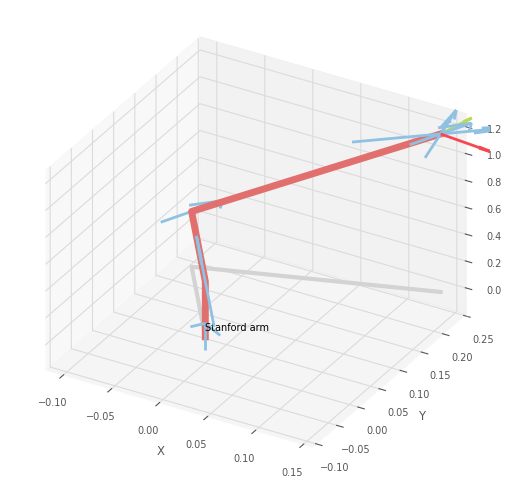

<Figure size 640x480 with 0 Axes>

In [15]:
q_end   = np.array([0.5, 0.3, 0.80, 0.4, -0.3, 0.5])
robot.plot(q_end)
plt.show()

The initial and final configurations of the Stanford manipulator were selected within the allowed joint limits.

The obtained figures show two different valid robot postures.  
Since the third joint of the Stanford manipulator is prismatic, its value is given in meters, while the remaining joint values are given in radians.

### 4. Plan the trajectory with prebuilt functions

In [22]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

print("q shape   =", tr.q.shape)
print("qd shape  =", tr.qd.shape)
print("qdd shape =", tr.qdd.shape)

q shape   = (100, 6)
qd shape  = (100, 6)
qdd shape = (100, 6)


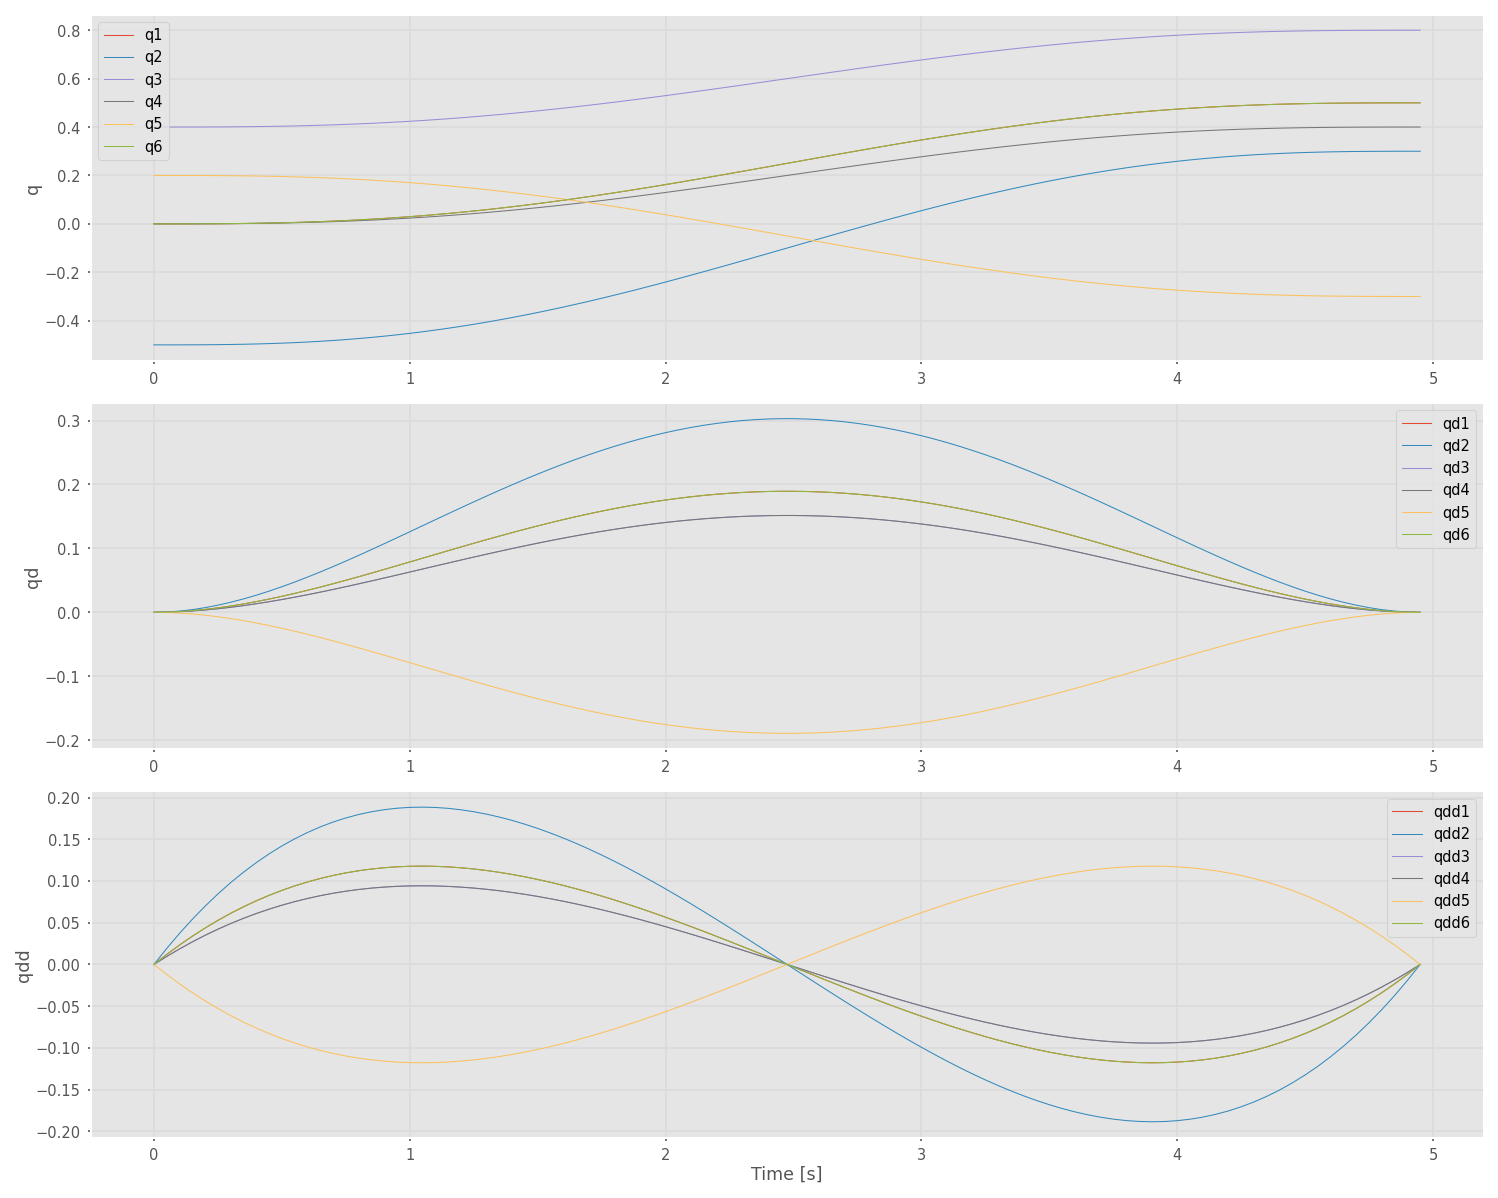

In [23]:
# Plot positions, velocities and accelerations

plt.figure(figsize=(10, 8), dpi=150)

for i in range(robot.n):
    plt.subplot(3, 1, 1)
    plt.plot(time, tr.q[:, i], label=f"q{i+1}")
    plt.ylabel("q")
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(time, tr.qd[:, i], label=f"qd{i+1}")
    plt.ylabel("qd")
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(time, tr.qdd[:, i], label=f"qdd{i+1}")
    plt.ylabel("qdd")
    plt.xlabel("Time [s]")
    plt.grid(True)

plt.subplot(3, 1, 1)
plt.legend()

plt.subplot(3, 1, 2)
plt.legend()

plt.subplot(3, 1, 3)
plt.legend()

plt.tight_layout()
plt.show()

The plotted curves show the joint positions, velocities, and accelerations generated by `jtraj`.  
The motion is smooth, and both the initial and final velocities are zero.  
For the Stanford manipulator, joint 3 is prismatic, so its position is given in meters, while the remaining joint positions are given in radians.

### 5. Solve the inverse dynamics

In [17]:
# Inverse dynamics using Newton-Euler method

# Case 1: non-zero velocities and accelerations
tau1 = robot.rne(tr.q, tr.qd, tr.qdd)

# Case 2: non-zero velocities and negligible accelerations
tau2 = robot.rne(tr.q, tr.qd, np.zeros((N, robot.n)))

# Case 3: zero velocities and accelerations
tau3 = robot.rne(tr.q, np.zeros((N, robot.n)), np.zeros((N, robot.n)))

print("tau1 shape =", tau1.shape)
print("tau2 shape =", tau2.shape)
print("tau3 shape =", tau3.shape)

tau1 shape = (100, 6)
tau2 shape = (100, 6)
tau3 shape = (100, 6)


### 6. Obtain the components of the dynamic equation

In [18]:
# Dynamic equation components

M = robot.inertia(tr.q)
C = robot.coriolis(tr.q, tr.qd)
G = robot.gravload(tr.q)


print("M shape =", M.shape)
print("C shape =", C.shape)
print("G shape =", G.shape)



M shape = (100, 6, 6)
C shape = (100, 6, 6)
G shape = (100, 6)


The matrices \( M(q) \), \( C(q,\dot{q}) \), and \( G(q) \) were computed for all time samples along the trajectory.  
For brevity, selected numerical values are shown for the first, middle, and final instants.

In [19]:
mid = N // 2

print("M at first time step:")
print(M[0])
print("\nC at first time step:")
print(C[0])
print("\nG at first time step:")
print(G[0])

print("\nM at middle time step:")
print(M[mid])
print("\nC at middle time step:")
print(C[mid])
print("\nG at middle time step:")
print(G[mid])

print("\nM at final time step:")
print(M[-1])
print("\nC at final time step:")
print(C[-1])
print("\nG at final time step:")
print(G[-1])

M at first time step:
[[ 4.24423690e+01  3.08105472e+00  3.39054594e-01  1.45435333e-01
   7.35165366e-01  2.58026801e-04]
 [ 3.08105472e+00  1.62440472e+02 -2.98260000e-01  3.05994798e-01
   2.12524530e-04 -5.96007992e-05]
 [ 3.39054594e-01 -2.98260000e-01  7.25200000e+00  4.21355639e-18
  -1.57828876e-01  0.00000000e+00]
 [ 1.45435333e-01  3.05994798e-01 -4.21355639e-18  3.61504377e-01
  -1.04841642e-03  2.94019973e-04]
 [ 7.35165366e-01  2.12524530e-04 -1.57828876e-01 -1.04841642e-03
   1.34201283e+00  1.83697020e-20]
 [ 2.58026801e-04 -5.96007992e-05  0.00000000e+00  2.94019973e-04
   1.83697020e-20  2.03000000e-02]]

C at first time step:
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

G at first time step:
[-1.77797967e-15 -1.16066938e+02  5.57007795e+01  7.42295174e-01
 -1.35876220e+00  0.00000000e+00]

M at middle time step:
[[ 7.08909635e+00  2.89840162e+00  8.93363888e-02  2.07716964e-01
   1.3391

### 7. Plot the graphs

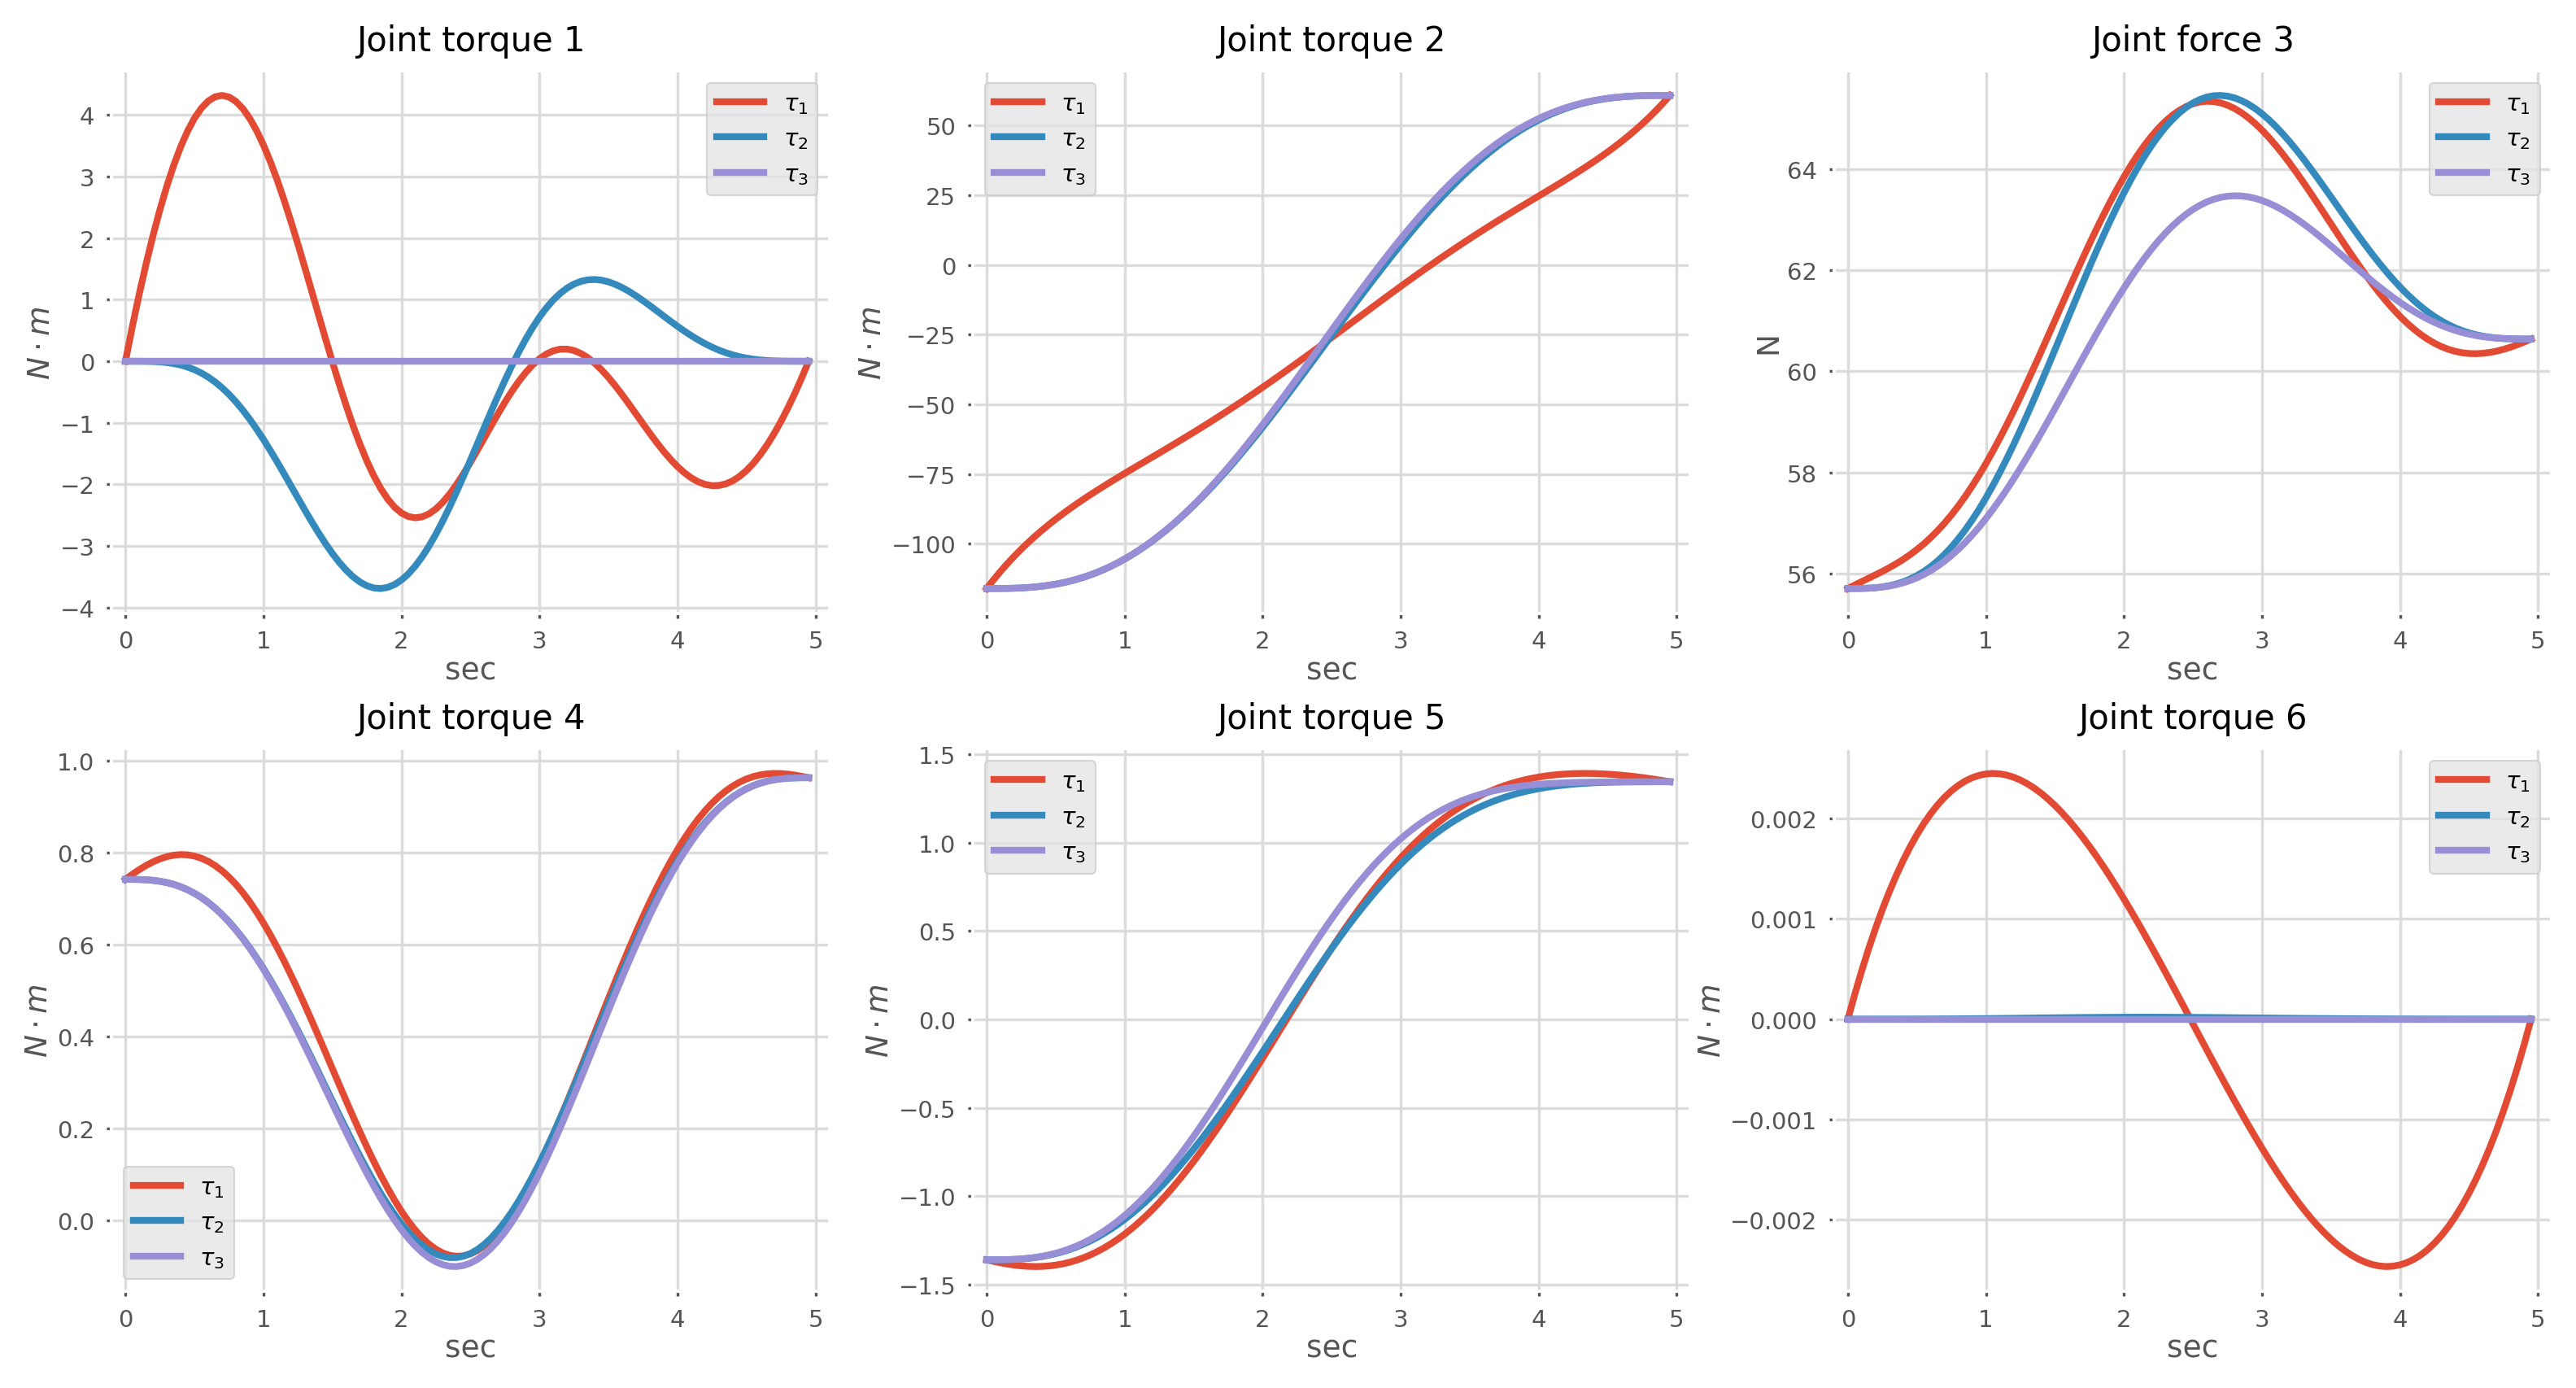

In [21]:
plt.figure(figsize=(10,5), dpi=300)

for g in range(6):
    plt.subplot(2,3,g+1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)

    plt.plot(time, tau1[:, g], linewidth=2, label=r"$\tau_1$")
    plt.plot(time, tau2[:, g], linewidth=2, label=r"$\tau_2$")
    plt.plot(time, tau3[:, g], linewidth=2, label=r"$\tau_3$")

    if g == 2:
        plt.title("Joint force 3", fontsize=10)
        plt.ylabel("N", fontsize=9)
    else:
        plt.title(f"Joint torque {g+1}", fontsize=10)
        plt.ylabel(r"$N \cdot m$", fontsize=9)

    plt.xlabel("sec", fontsize=9)
    plt.grid(True)
    plt.legend()

    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1, t_stop+0.1])

plt.show()

For the Stanford manipulator, joint 3 is prismatic.  
Therefore, the plotted quantity for joint 3 is force in \(N\), while for the remaining joints the plotted quantities are torques in \(N \cdot m\).

The actuation plots for all six joints were obtained for the three considered cases.
For the revolute joints, the plotted quantities are torques, while for the third prismatic joint the plotted quantity is force.
The first case corresponds to non-zero velocities and accelerations, the second case corresponds to non-zero velocities with negligible accelerations, and the third case corresponds to zero velocities and accelerations.